# FIN 4000 — Chapter 12: Behavioral Finance and Technical Analysis
*When psychology moves markets — behavioral biases and technical analysis tools*

**ANSWER KEY — fully worked, instructor reference**

This notebook is the Python companion to the Chapter 12 Excel template — same data, same formulas, same numbers. Where the Excel workshop has you build a formula in a cell, this notebook has you build it in a line of Python instead.

## Step 1 — Entry Quiz *(3 minutes, individually)*

1. What's the difference between overconfidence and confirmation bias?
2. What does “limits to arbitrage” mean, and why does it matter for whether mispricing gets corrected?
3. What is a moving average, and what is it meant to signal in technical analysis?

---

In [1]:
import numpy as np

## Step 2 — Worked Example *(10 minutes, instructor-led)*

Compute a 5-day simple moving average for a stock given 5 days of closing prices, and compare today's price to the moving average.

In [2]:
import pandas as pd
prices = pd.Series([48, 50, 52, 51, 54, 55, 53],
                    index=range(1, 8), name='Close')
prices

1    48
2    50
3    52
4    51
5    54
6    55
7    53
Name: Close, dtype: int64

In [3]:
sma5 = prices.rolling(5).mean()
print(sma5)
print(f"\nToday's price ({prices.iloc[4]}) vs. 5-day SMA ({sma5.iloc[4]:.2f})")

1     NaN
2     NaN
3     NaN
4     NaN
5    51.0
6    52.4
7    53.0
Name: Close, dtype: float64

Today's price (54) vs. 5-day SMA (51.00)


*SMA = (48+50+52+51+54)÷5 = $51.00. Today's price ($54) is above the SMA — a classic bullish signal in technical analysis, though EMH would say this pattern shouldn't predict future returns.*

## Step 3 — Pair Work *(12 minutes, with a partner)*

**1.** Compute a 3-day SMA using just the most recent 3 days ($52, $51, $54). How does it compare to the 5-day SMA, and which reacts faster to new information?

In [4]:
sma3 = prices.rolling(3).mean()
print(sma3)

1          NaN
2          NaN
3    50.000000
4    51.000000
5    52.333333
6    53.333333
7    54.000000
Name: Close, dtype: float64


**2.** Name one behavioral bias that could explain why a stock might “overreact” to good news and then partially reverse in the following weeks.

*(Conceptual — name a bias with your partner.)*

**3.** A momentum trader believes “the trend is your friend.” Which behavioral bias might explain why momentum, once started, tends to persist for a while?

*(Conceptual — discuss with your partner.)*

## Step 4 — Python Pass *(7 minutes)*

- Both moving averages (3-day and 5-day), built as formulas that update automatically as new prices are added
- A simple signal column: TRUE/FALSE for whether today's price is above each moving average
- The same data extended a few more days, so the moving averages visibly shift as the window rolls forward

1    False
2    False
3    False
4    False
5     True
6     True
7    False
Name: Close, dtype: bool


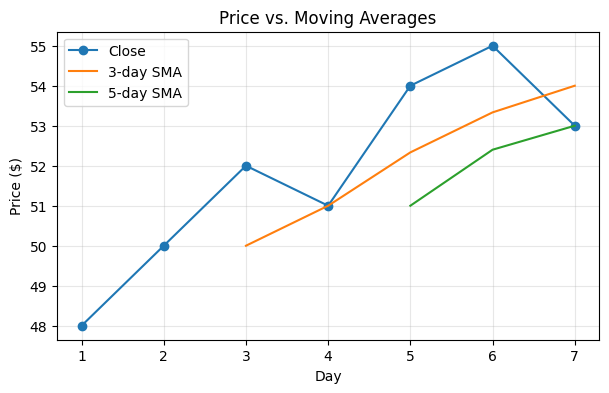

In [5]:
import matplotlib.pyplot as plt
above_sma5 = prices > sma5
print(above_sma5)

plt.figure(figsize=(7, 4))
plt.plot(prices.index, prices, marker='o', label='Close')
plt.plot(sma3.index, sma3, label='3-day SMA')
plt.plot(sma5.index, sma5, label='5-day SMA')
plt.xlabel('Day'); plt.ylabel('Price ($)')
plt.title('Price vs. Moving Averages'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## Step 5 — Discussion *(3-5 minutes, no calculation)*

> Even if you personally believe markets are largely efficient, why might it still make sense to understand behavioral biases and technical analysis?